# Applying Numerics to the Mass-Spring System (Runge-Kutta Method)

**Methods:** Numerical integration (Euler, Heun/RK2, RK4) vs analytical solution; NumPy, Matplotlib

### Overview
This notebook compares the accuracy of three numerical methods: Euler's method, Heun's method, and the 4th Order Runge-Kutta method.

----

### Details:

Apply the Euler and 4th Order Runge-Kutta Method to the Mass-Spring system governed by the following 2nd order ODE,

$$
\frac{d^2X}{dt^2}+\omega^2_pX=F_p\sin{\omega t}
$$
$$
X(0)=X'(0)=0
$$

#### Mass-spring set-up:

**Natural angular frequency**: $\omega_p$ = $\pi$ per second <br/>

**External angular frequency**: $\omega$ = $2\pi$ per second <br/>

**External amplitude**: $F_p$ = 80 m/$s^2$ <br/>

This notebook tests how the time-increment ($\Delta t$) affects the accuracy of the numerical methods by comparing the results obtained using time intervals of 0.01 s, 0.05 s, and 0.1 s. The accuracy is evaluated through the following two types of plots:

1. **Time-series** ($t$ vs. $X$): Compare how changing $\Delta t$ affects the numerical solutions and their agreement with the exact solution.
2. **Phase-diagram** ($X'$ vs. $X$): Compare how changing $\Delta t$ affects the phase diagrams produced by the numerical methods.

### Reference:

we call that the exact solution for the above initial conditions and angular frequency relationships ($\omega_p\neq\omega$) is:

$$
X = \frac{F_p}{\omega^2_p-\omega^2}(-\frac{\omega}{\omega_p}\sin{\omega_pt}+\sin{\omega t})
$$

$$
X'=\frac{F_p\omega}{\omega^2_p-\omega^2}(-\cos{\omega_pt}+\cos{\omega t})
$$

Python representation of the exact solution:

``` python
Xexact = Fp*(-(w/wp)*np.sin(wp*t)+np.sin(w*t))/(wp*wp-w*w)
Vexact = Fp*w*(-np.cos(wp*t)+np.cos(w*t))/(wp*wp-w*w)
```

Runge-Kutta methods of higher-order ODEs:

Substitute higher-order derivative terms with variables creating simultaneous 1st-order ODEs. The above ODE will be comprised of two simultaneous ODEs,

$\frac{dX}{dt}=V$

$\frac{dV}{dt}=-\omega^2_pX+F_p\sin{\omega t}$

---

### Program

#### Importing necessary modules and defining shared parameters

In [12]:
import numpy as np
import matplotlib.pyplot as plt
w = 2*np.pi
wp = np.pi
Fp = 80

#### Define the functions that conduct approximate solutions

In [13]:
def dXdt(t,X,V):
  return V

def dVdt(t,X,V):
  return -wp*wp*X + Fp*np.sin(w*t)

def exact(t):
  X = Fp*(-(w/wp)*np.sin(wp*t)+np.sin(w*t))/(wp*wp-w*w)
  V = Fp*w*(-np.cos(wp*t)+np.cos(w*t))/(wp*wp-w*w)
  return X,V

def euler(t):
  X = np.zeros_like(t)
  V = np.zeros_like(t)
  X[0] = 0.0
  V[0] = 0.0
  for n in range(0,t.shape[0]-1):
    h = dt*dXdt(t[n], X[n], V[n])
    g = dt*dVdt(t[n], X[n], V[n])
    X[n+1] = X[n]+h
    V[n+1] = V[n]+g
  return X,V

def rk(t):
  X = np.zeros_like(t)
  V = np.zeros_like(t)
  X[0] = 0.0
  V[0] = 0.0
  for n in range(0,t.shape[0]-1):
    h1 = dt*dXdt(t[n], X[n], V[n])
    g1 = dt*dVdt(t[n], X[n], V[n])
    h2 = dt*dXdt(t[n]+dt/2.0, X[n]+h1/2.0, V[n]+g1/2.0)
    g2 = dt*dVdt(t[n]+dt/2.0, X[n]+h1/2.0, V[n]+g1/2.0)
    h3 = dt*dXdt(t[n]+dt/2.0, X[n]+h2/2.0, V[n]+g2/2.0)
    g3 = dt*dVdt(t[n]+dt/2.0, X[n]+h2/2.0, V[n]+g2/2.0)
    h4 = dt*dXdt(t[n]+dt, X[n]+h3, V[n]+g3)
    g4 = dt*dVdt(t[n]+dt, X[n]+h3, V[n]+g3)
    X[n+1] = X[n]+(h1+2*h2+2*h3+h4)/6
    V[n+1] = V[n]+(g1+2*g2+2*g3+g4)/6
  return X,V

def heun(t): #2nd order RK
  X = np.zeros_like(t)
  V = np.zeros_like(t)
  X[0] = 0.0
  V[0] = 0.0
  for n in range(0,t.shape[0]-1):
    h1 = dt*dXdt(t[n], X[n], V[n])
    g1 = dt*dVdt(t[n], X[n], V[n])
    h2 = dt*dXdt(t[n]+dt, X[n]+h1, V[n]+g1)
    g2 = dt*dVdt(t[n]+dt, X[n]+h1, V[n]+g1)
    X[n+1] = X[n]+(h1+h2)/2
    V[n+1] = V[n]+(g1+g2)/2
  return X,V

The above functions are functions for exact solution and numerical methods.

#### Solution for numerical methods at `dt=0.01`

##### Set solutions for each functions for `dt=0.01`

In [14]:
%%time
dt = 0.01
t = np.arange(0.0,10.0+dt,dt)
Xrk,Vrk = rk(t)
Xheun,Vheun = heun(t)
Xexact,Vexact = exact(t)
Xeuler,Veuler = euler(t)

CPU times: total: 0 ns
Wall time: 9.51 ms


##### Visualizing the time-series of `X` for a `dt=0.01`

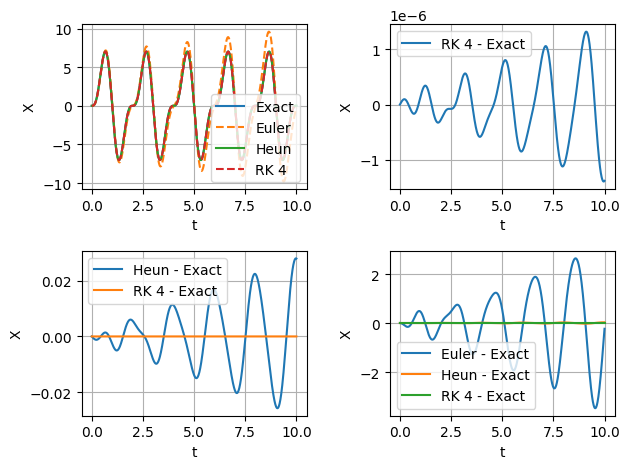

In [15]:
fig, ax = plt.subplots(2,2)
ax[0,0].plot(t,Xexact, label = "Exact")
ax[0,0].plot(t,Xeuler,linestyle='dashed', label = "Euler")
ax[0,0].plot(t,Xheun, label = "Heun")
ax[0,0].plot(t,Xrk,linestyle='dashed', label = "RK 4")
ax[0,0].set_xlabel('t')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(t,Xrk-Xexact,label = "RK 4 - Exact")
ax[0,1].set_xlabel('t')
ax[0,1].set_ylabel('X')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(t,Xheun-Xexact,label = "Heun - Exact")
ax[1,0].plot(t,Xrk-Xexact,label = "RK 4 - Exact")
ax[1,0].set_xlabel('t')
ax[1,0].set_ylabel('X')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1,1].plot(t,Xeuler-Xexact,label = "Euler - Exact")
ax[1,1].plot(t,Xheun-Xexact,label = "Heun - Exact")
ax[1,1].plot(t,Xrk-Xexact,label = "RK 4 - Exact")
ax[1,1].set_xlabel('t')
ax[1,1].set_ylabel('X')
ax[1,1].legend()
ax[1,1].grid(True)
plt.tight_layout()

As we can see, the top-left graph obtained from the exact solution, Euler method, Heun method, and RK4 method with $\Delta t = 0.01$ is very close across all methods. Since $\Delta t = 0.01$ provides more detailed results than $\Delta t = 0.05$ and $\Delta t = 0.10$, we also illustrate the difference between each numerical method and the exact solution. From the top-right graph, RK4 still shows a small difference from the exact solution. The bottom row shows that the Heun and Euler methods have decreasing levels of accuracy compared to the exact solution, respectively.

##### Visualizing the phase-diagram for a `dt=0.01`

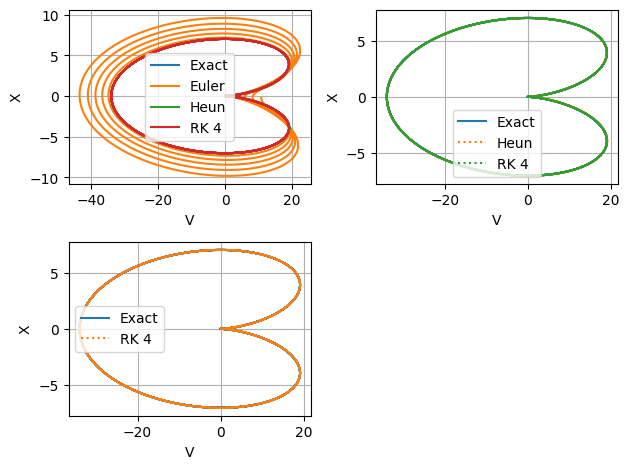

In [16]:
fig, ax = plt.subplots(2,2)
ax[0,0].plot(Vexact,Xexact,label = "Exact")
ax[0,0].plot(Veuler,Xeuler,label = "Euler")
ax[0,0].plot(Vheun,Xheun,label = "Heun")
ax[0,0].plot(Vrk,Xrk,label = "RK 4")
ax[0,0].set_xlabel('V')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(Vexact,Xexact,label = "Exact")
ax[0,1].plot(Vheun,Xheun,linestyle=':',label = "Heun")
ax[0,1].plot(Vrk,Xrk,linestyle=':',label = "RK 4")
ax[0,1].set_xlabel('V')
ax[0,1].set_ylabel('X')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(Vexact,Xexact,label = "Exact")
ax[1,0].plot(Vrk,Xrk,linestyle=':',label = "RK 4")
ax[1,0].set_xlabel('V')
ax[1,0].set_ylabel('X')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1, 1].axis('off')
plt.tight_layout()

Phase diagram for $\Delta t = 0.01$ of Heun and RK4 method is hardly to see the difference from the graph. However, the Euler method deviates significantly over time, causing the spiral to expand outward. This shows that the Euler method cause error much more quickly and is unstable for long time interval prediction.

#### Solution for numerical methods at `dt=0.05`

##### Set solutions for each functions for `dt=0.05`

In [17]:
%%time
dt = 0.05
t = np.arange(0.0,10.0+dt,dt)
Xrk,Vrk = rk(t)
Xheun,Vheun = heun(t)
Xexact,Vexact = exact(t)
Xeuler,Veuler = euler(t)

CPU times: total: 0 ns
Wall time: 2 ms


##### Visualizing the time-series of `X` for a `dt=0.05`

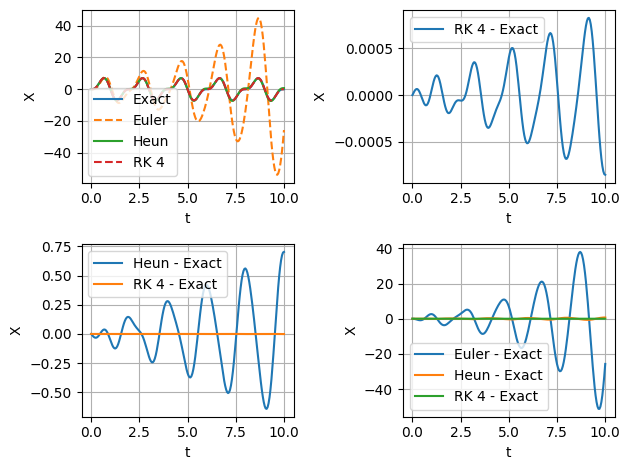

In [18]:
fig, ax = plt.subplots(2,2)
ax[0,0].plot(t,Xexact, label = "Exact")
ax[0,0].plot(t,Xeuler,linestyle='dashed', label = "Euler")
ax[0,0].plot(t,Xheun, label = "Heun")
ax[0,0].plot(t,Xrk,linestyle='dashed', label = "RK 4")
ax[0,0].set_xlabel('t')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(t,Xrk-Xexact,label = "RK 4 - Exact")
ax[0,1].set_xlabel('t')
ax[0,1].set_ylabel('X')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(t,Xheun-Xexact,label = "Heun - Exact")
ax[1,0].plot(t,Xrk-Xexact,label = "RK 4 - Exact")
ax[1,0].set_xlabel('t')
ax[1,0].set_ylabel('X')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1,1].plot(t,Xeuler-Xexact,label = "Euler - Exact")
ax[1,1].plot(t,Xheun-Xexact,label = "Heun - Exact")
ax[1,1].plot(t,Xrk-Xexact,label = "RK 4 - Exact")
ax[1,1].set_xlabel('t')
ax[1,1].set_ylabel('X')
ax[1,1].legend()
ax[1,1].grid(True)
plt.tight_layout()

Now as $\Delta t = 0.05$, Euler method shows a much larger difference from the exact solution and the others 2 methods.

The different of Euler method to exact solution compared to Heun and RK4 method is significantly larger.

##### Visualizing the phase-diagram for a `dt=0.05`

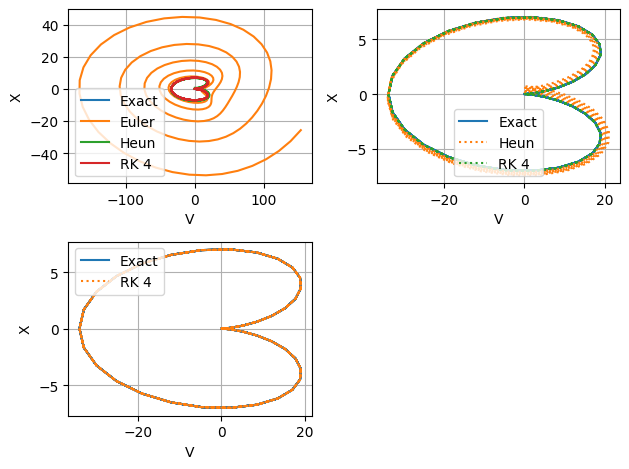

In [19]:
fig, ax = plt.subplots(2,2)
ax[0,0].plot(Vexact,Xexact,label = "Exact")
ax[0,0].plot(Veuler,Xeuler,label = "Euler")
ax[0,0].plot(Vheun,Xheun,label = "Heun")
ax[0,0].plot(Vrk,Xrk,label = "RK 4")
ax[0,0].set_xlabel('V')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(Vexact,Xexact,label = "Exact")
ax[0,1].plot(Vheun,Xheun,linestyle=':',label = "Heun")
ax[0,1].plot(Vrk,Xrk,linestyle=':',label = "RK 4")
ax[0,1].set_xlabel('V')
ax[0,1].set_ylabel('X')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(Vexact,Xexact,label = "Exact")
ax[1,0].plot(Vrk,Xrk,linestyle=':',label = "RK 4")
ax[1,0].set_xlabel('V')
ax[1,0].set_ylabel('X')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1, 1].axis('off')
plt.tight_layout()

Now that the phase diagram is set to be $\Delta t = 0.05$, Heun method is starting to show some difference from RK4 and Exact solution. However, Euler method still performs worse as expected, but this time much worst than previous case of $\Delta t = 0.01$ as the spiral expands outward much faster.

#### Solution for numerical methods at `dt=0.10`

##### Set solutions for each functions for `dt=0.10`

In [20]:
%%time
dt = 0.10
t = np.arange(0.0,10.0+dt,dt)
Xrk,Vrk = rk(t)
Xheun,Vheun = heun(t)
Xexact,Vexact = exact(t)
Xeuler,Veuler = euler(t)

CPU times: total: 0 ns
Wall time: 1e+03 μs


##### Visualizing the time-series of `X` for a `dt=0.10`

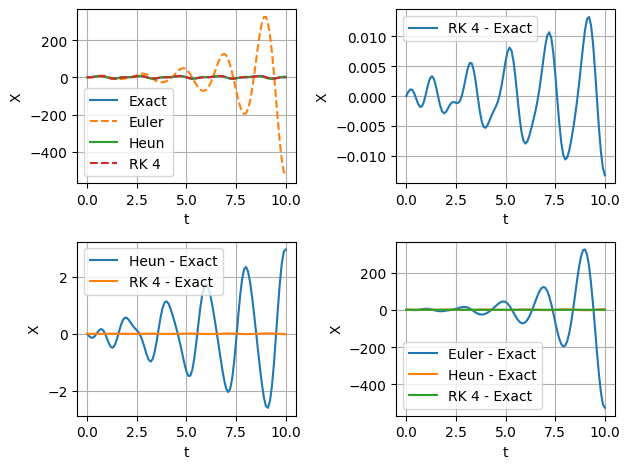

In [21]:
fig, ax = plt.subplots(2,2)
ax[0,0].plot(t,Xexact, label = "Exact")
ax[0,0].plot(t,Xeuler,linestyle='dashed', label = "Euler")
ax[0,0].plot(t,Xheun, label = "Heun")
ax[0,0].plot(t,Xrk,linestyle='dashed', label = "RK 4")
ax[0,0].set_xlabel('t')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(t,Xrk-Xexact,label = "RK 4 - Exact")
ax[0,1].set_xlabel('t')
ax[0,1].set_ylabel('X')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(t,Xheun-Xexact,label = "Heun - Exact")
ax[1,0].plot(t,Xrk-Xexact,label = "RK 4 - Exact")
ax[1,0].set_xlabel('t')
ax[1,0].set_ylabel('X')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1,1].plot(t,Xeuler-Xexact,label = "Euler - Exact")
ax[1,1].plot(t,Xheun-Xexact,label = "Heun - Exact")
ax[1,1].plot(t,Xrk-Xexact,label = "RK 4 - Exact")
ax[1,1].set_xlabel('t')
ax[1,1].set_ylabel('X')
ax[1,1].legend()
ax[1,1].grid(True)
plt.tight_layout()

Now we've come to our last case of `dt=0.10` , as expected of every method, the difference of value from exact solution is getting much more significant.



##### Visualizing the phase-diagram for a `dt=0.10`

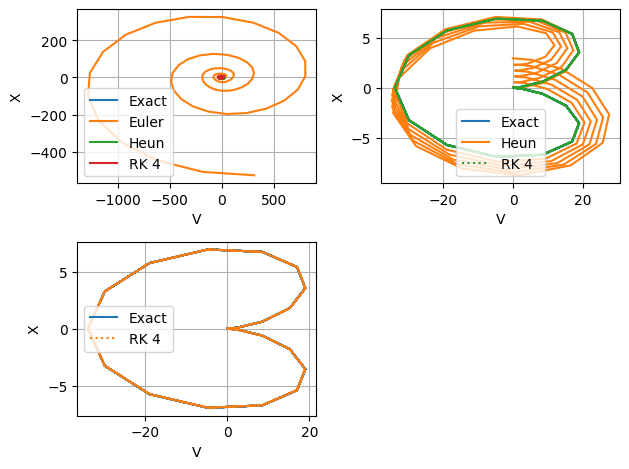

In [22]:
fig, ax = plt.subplots(2,2)
ax[0,0].plot(Vexact,Xexact,label = "Exact")
ax[0,0].plot(Veuler,Xeuler,label = "Euler")
ax[0,0].plot(Vheun,Xheun,label = "Heun")
ax[0,0].plot(Vrk,Xrk,label = "RK 4")
ax[0,0].set_xlabel('V')
ax[0,0].set_ylabel('X')
ax[0,0].legend()
ax[0,0].grid(True)
ax[0,1].plot(Vexact,Xexact,label = "Exact")
ax[0,1].plot(Vheun,Xheun,label = "Heun")
ax[0,1].plot(Vrk,Xrk,linestyle=':',label = "RK 4")
ax[0,1].set_xlabel('V')
ax[0,1].set_ylabel('X')
ax[0,1].legend()
ax[0,1].grid(True)
ax[1,0].plot(Vexact,Xexact,label = "Exact")
ax[1,0].plot(Vrk,Xrk,linestyle=':', label = "RK 4")
ax[1,0].set_xlabel('V')
ax[1,0].set_ylabel('X')
ax[1,0].legend()
ax[1,0].grid(True)
ax[1, 1].axis('off')
plt.tight_layout()

Now that the phase diagram is set to be $\Delta t = 0.10$, Heun method is shows a lot more difference from RK4 and Exact solution, the spiral clearly expanded outward. And as expected, Euler method becomes unstable with this $\Delta t = 0.10$ setup, it deviates much more over time, causing the spiral to largely expand outward.

---

In conclusion, as the time step $\Delta t$ increases, numerical methods accumulate more error. For example, Euler’s method with large $\Delta t$ result a lot more deviates graph from the exact solution, while RK4 remains accurate. This demonstrates the trade-off between computational cost and accuracy. However, there is something in exchange for more accuracy as we see the run time for $\Delta t=0.01, 0.05,$ and $0.10$ is `9.51ms, 2ms, and 1ms`, respectively. Therefore, the more accuracy we want the more time we used.